# Lab 8: Retrieval-Augmented Generation (RAG)

Large Language Models (LLMs) speichern ihr Wissen in den Modellparametern doch dieses Wissen ist statisch. Es ist zum Trainingszeitpunkt eingefroren, lässt sich nicht ohne erneutes Training aktualisieren und gibt keine Auskunft darüber, woher eine Antwort stammt. Das führt zu Halluzinationen, besonders bei aktuellen Ereignissen, Nischenthemen oder privaten Daten.

Retrieval-Augmented Generation (RAG) kombiniert dazu einen Retriever mit einem Generator. Statt sich nur auf sein parametrisches Gedächtnis zu verlassen, ruft das Modell zunächst relevante Textstellen aus einer externen Wissensquelle ab und erzeugt seine Antwort auf Basis dieses Kontexts. 



## 8.1 Architektur eines RAG-Systems:
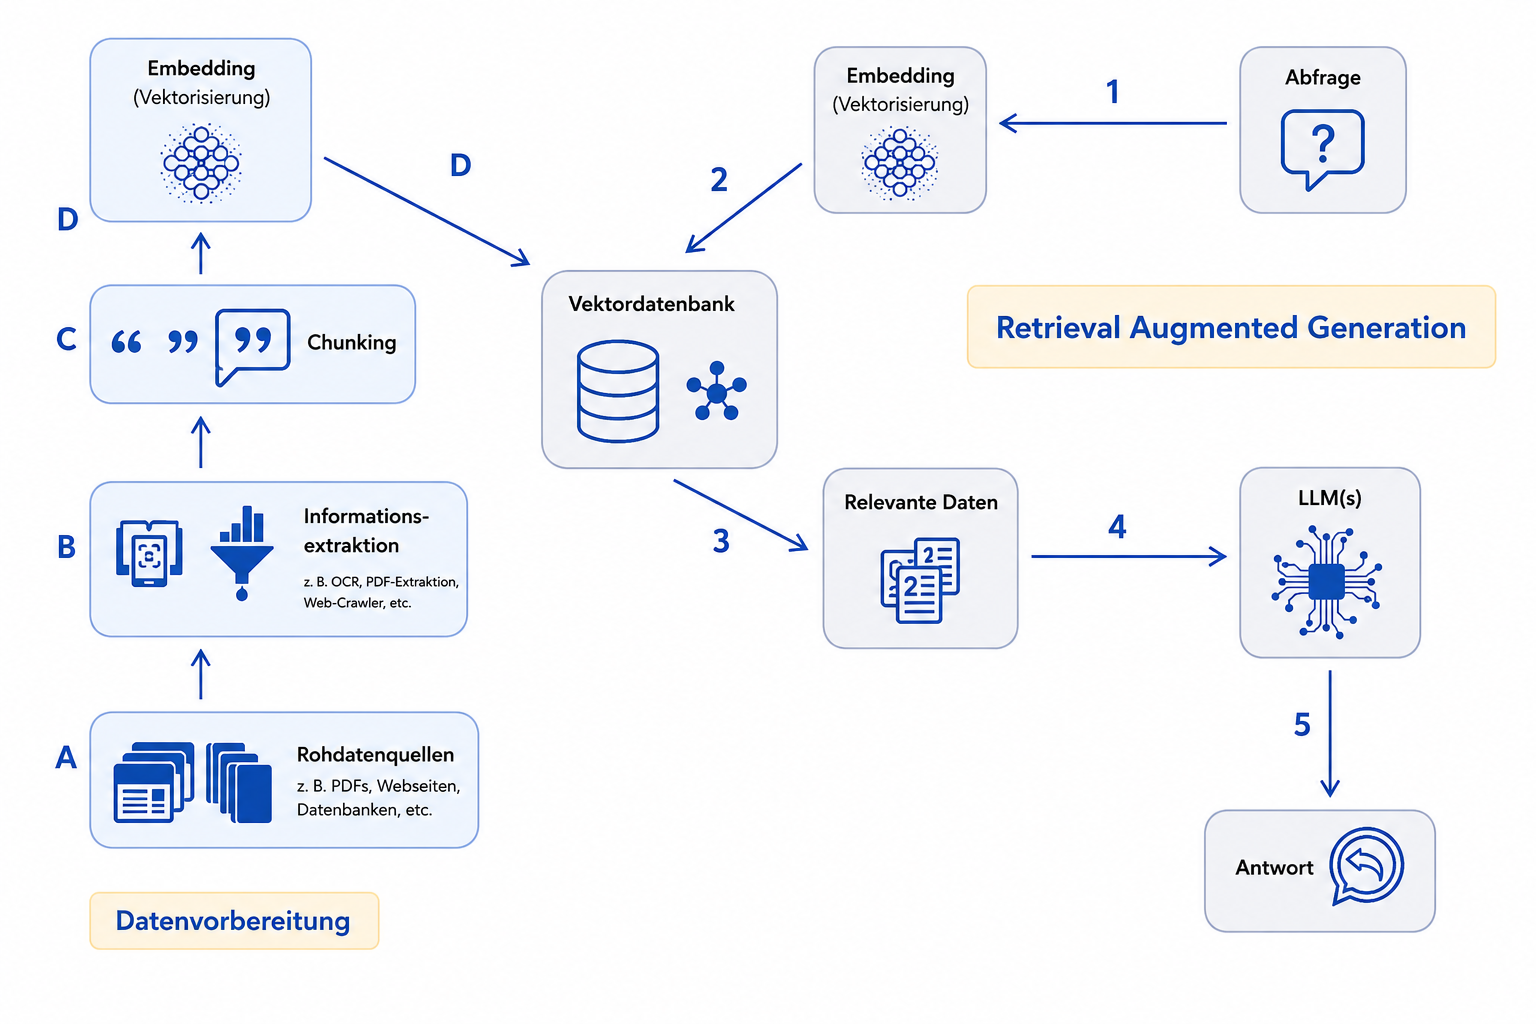 Quelle: OpenAI Images 2 Input: Stil + https://gradientflow.com/wp-content/uploads/2023/10/newsletter87-RAG-simple.png

- Die Schritte A–D zeigen die Datenvorbereitung eines RAG-Systems. Dabei werden externe Datenquellen zunächst gesammelt, bereinigt und in kleinere Textabschnitte aufgeteilt. Diese sogenannten Chunks werden anschließend in Embeddings umgewandelt und in einer Vektordatenbank gespeichert.

- Die Schritte 1–5 zeigen, was während einer Anfrage an das RAG-System passiert:

    1. Query vektorisieren -->
    Die Nutzeranfrage wird in ein Embedding umgewandelt, damit sie mit den gespeicherten Dokument-Chunks verglichen werden kann.

    2. Ähnliche Chunks suchen -->
    Das Query-Embedding wird mit den Embeddings in der Vektordatenbank verglichen. Dabei werden die semantisch ähnlichsten bzw. relevantesten Chunks identifiziert.

    3. Relevante Daten abrufen -->
    Die passendsten Chunks werden aus der Vektordatenbank zurückgegeben und als zusätzliche Kontextinformationen bereitgestellt.

    4. Kontext an das LLM übergeben -->
    Die ursprüngliche Anfrage und die abgerufenen relevanten Daten werden gemeinsam an das Sprachmodell übergeben.

    5. Antwort generieren -->
    Das LLM erzeugt auf Basis der Anfrage und der zusätzlich bereitgestellten Informationen eine Antwort.

In diesem Beispiel verwenden wir Ollama, ein Kommandozeilen-Tool, mit dem sich Modelle von Hugging Face lokal betreiben lassen.

Als Modelle nutzen wir:

Embedding-Modell: [hf.co/CompendiumLabs/bge-base-en-v1.5-gguf](https://huggingface.co/CompendiumLabs/bge-base-en-v1.5-gguf)

Sprachmodell (LLM):[hf.co/bartowski/Llama-3.2-1B-Instruct-GGUF](https://huggingface.co/bartowski/Llama-3.2-1B-Instruct-GGUF) 

Als Datensatz verwenden wir unseren Pretraining-Korpus [RecipeNLG](https://recipenlg.cs.put.poznan.pl). Jedes Rezept (bestehend aus Titel, Zutaten und Zubereitungsanleitung) wird dabei als ein Chunk behandelt und bildet die Wissensbasis, aus der in der Indexing-Phase die Embeddings erzeugt werden.

## 8.2 Modelle und Datensatz vorbereiten

Zunächst muss Ollam heruntergeladen werden: [Download Ollama](https://ollama.com/)

Danach Modelle herunterladen:

ollama pull hf.co/CompendiumLabs/bge-base-en-v1.5-gguf

ollama pull hf.co/bartowski/Llama-3.2-1B-Instruct-GGUF

### Notwendige Bibliotheken:

In [1]:
import pandas as pd
import ollama

### Datensatz Laden
- hier können wir den Code aus Lab2 wiederverwenden:

In [2]:
# Reduzierter Datensatz mit 100k Zeilen zum Testen
cloud_url = "https://syncandshare.lrz.de/dl/fiHE8nDPcb4nww3VCn4QmN/reduced_dataset_100k.csv"
# Die folgende Zeile einkommentieren, um den vollständigen Datensatz zu verwenden
# cloud_url = "https://syncandshare.lrz.de/dl/finR5gtyQx3FNL5P2hz6H/full_dataset.csv"
try:
    df = pd.read_csv(cloud_url)
except Exception as e:
    print(f'{e}')

if __name__ == '__main__':

    try:
        print("Lade Datensatz aus der Cloud...")
        #df = pd.read_csv(cloud_url)
        print("Datensatz erfolgreich geladen!\n")
        print("Info:")
        print(df.info())
        print("")
        print("Anfang (Head) des Datensatzes:")
        print(df.head())
        
    except Exception as e:
        print(f"Ein Fehler ist beim Laden des Datensatzes aufgetreten: {e}")

Lade Datensatz aus der Cloud...
Datensatz erfolgreich geladen!

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Unnamed: 0   100000 non-null  int64 
 1   title        100000 non-null  object
 2   ingredients  100000 non-null  object
 3   directions   100000 non-null  object
 4   link         100000 non-null  object
 5   source       100000 non-null  object
 6   NER          100000 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None

Anfang (Head) des Datensatzes:
   Unnamed: 0                  title  \
0           0    No-Bake Nut Cookies   
1           1  Jewell Ball'S Chicken   
2           2            Creamy Corn   
3           3          Chicken Funny   
4           4   Reeses Cups(Candy)     

                                         ingredients  \
0  ["1 c. firmly packed brown sugar", "1/2 c. eva...   
1  

In [3]:
def format_csv(row):
    title = str(row['title'])
    ingredients = str(row['ingredients']).replace('[', '').replace(']', '').replace("'", "").replace('"', '')
    directions = str(row['directions']).replace('[', '').replace(']', '').replace("'", "").replace('"', '')
    return f"Recepie: {title}\nIngredients: {ingredients}\nDirections: {directions}"


dataset = df.apply(format_csv, axis=1).tolist()
dataset = dataset[:1000]  # Zum Testen auf die ersten 1000 Einträge beschränken


if __name__ == '__main__':
    print(f"Anzahl Einträge: {len(dataset)}")
    print("\nVorschau des ersten Eintrags:")
    print(dataset[:1])

Anzahl Einträge: 1000

Vorschau des ersten Eintrags:
['Recepie: No-Bake Nut Cookies\nIngredients: 1 c. firmly packed brown sugar, 1/2 c. evaporated milk, 1/2 tsp. vanilla, 1/2 c. broken nuts (pecans), 2 Tbsp. butter or margarine, 3 1/2 c. bite size shredded rice biscuits\nDirections: In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine., Stir over medium heat until mixture bubbles all over top., Boil and stir 5 minutes more. Take off heat., Stir in vanilla and cereal; mix well., Using 2 teaspoons, drop and shape into 30 clusters on wax paper., Let stand until firm, about 30 minutes.']


Die einzige Unterschied im Gegensatz zu dem Code in Lab2 ist, dass wir für RAG jedes Rezept als eigenständigen Chunk (Liste statt einem langen String) behandeln.

## 8.3 Vektordatenbank implementieren
Nun implementieren wir die Vektordatenbank.

Wir nutzen das Embedding-Modell von Ollama, um jeden Chunk (also jedes Rezept) in einen Embedding-Vektor umzuwandeln, und speichern anschließend den Chunk zusammen mit seinem zugehörigen Vektor in einer Liste.

Hier eine Beispielfunktion, die den Embedding-Vektor für einen gegebenen Text berechnet:

In [4]:


EMBEDDING_MODEL = 'hf.co/CompendiumLabs/bge-base-en-v1.5-gguf'
LANGUAGE_MODEL = 'hf.co/bartowski/Llama-3.2-1B-Instruct-GGUF'

# Jedes Element in VECTOR_DB ist ein Tupel (chunk, embedding)
# Das Embedding ist eine Liste von Floats, zum Beispiel: [0.1, 0.04, -0.34, 0.21, ...]
VECTOR_DB = []

def add_chunk_to_database(chunk):
  embedding = ollama.embed(model=EMBEDDING_MODEL, input=chunk)['embeddings'][0]
  VECTOR_DB.append((chunk, embedding))

##### add_chunk_to_database verwenden:

In [5]:
for i, chunk in enumerate(dataset): 
  add_chunk_to_database(chunk)
  print(f'Added chunk {i+1}/{len(dataset)} to the database')

Added chunk 1/1000 to the database
Added chunk 2/1000 to the database
Added chunk 3/1000 to the database
Added chunk 4/1000 to the database
Added chunk 5/1000 to the database
Added chunk 6/1000 to the database
Added chunk 7/1000 to the database
Added chunk 8/1000 to the database
Added chunk 9/1000 to the database
Added chunk 10/1000 to the database
Added chunk 11/1000 to the database
Added chunk 12/1000 to the database
Added chunk 13/1000 to the database
Added chunk 14/1000 to the database
Added chunk 15/1000 to the database
Added chunk 16/1000 to the database
Added chunk 17/1000 to the database
Added chunk 18/1000 to the database
Added chunk 19/1000 to the database
Added chunk 20/1000 to the database
Added chunk 21/1000 to the database
Added chunk 22/1000 to the database
Added chunk 23/1000 to the database
Added chunk 24/1000 to the database
Added chunk 25/1000 to the database
Added chunk 26/1000 to the database
Added chunk 27/1000 to the database
Added chunk 28/1000 to the database
A

## 8.4 Retreaval Funktion implementieren
Als Nächstes implementieren wir die Retrieval-Funktion, die eine Anfrage (Query) entgegennimmt und die Top-N relevantesten Chunks auf Basis der Kosinus-Ähnlichkeit zurückgibt. Dabei gilt: Je höher die Kosinus-Ähnlichkeit zwischen zwei Vektoren ist, desto „näher" liegen sie im Vektorraum – das bedeutet, sie sind sich inhaltlich (semantisch) ähnlicher.

Hier eine Beispielfunktion, die die Kosinus-Ähnlichkeit zwischen zwei Vektoren berechnet:

In [6]:
def cosine_similarity(a, b):
  dot_product = sum([x * y for x, y in zip(a, b)])
  norm_a = sum([x ** 2 for x in a]) ** 0.5
  norm_b = sum([x ** 2 for x in b]) ** 0.5
  return dot_product / (norm_a * norm_b)

##### Damit lässt sich jetzt die Retreaval Funktion implementieren:

In [7]:
def retrieve(query, top_n=3): # top_n gibt an, wie viele der relevantesten Chunks zurückgegeben werden sollen
  # Zuerst berechnen wir das Embedding für die Abfrage
  query_embedding = ollama.embed(model=EMBEDDING_MODEL, input=query)['embeddings'][0]

  # temporäre Liste, um die Ähnlichkeiten zu speichern
  similarities = []

  # Dann berechnen wir die Ähnlichkeit zwischen dem Abfrage-Embedding und jedem Chunk-Embedding in der Datenbank
  for chunk, embedding in VECTOR_DB:
    similarity = cosine_similarity(query_embedding, embedding)
    similarities.append((chunk, similarity))
  # sortieren der Chunks basierend auf der Ähnlichkeit (höchste zuerst)
  similarities.sort(key=lambda x: x[1], reverse=True)
  # Rückgabe der top_n Chunks mit der höchsten Ähnlichkeit
  return similarities[:top_n]


##### retrieve Funktion testen:

In [8]:
# Beispielquery initialisieren
query_1 = "How to make a chocolate cake?"
query_2 = "What are the ingredients for a vegan lasagna?"
query_3 = "How many Teams are in the Bundesliga?"

results_1 = retrieve(query_1)
results_2 = retrieve(query_2)
results_3 = retrieve(query_3)

print(f"Top 3 Ergebnisse für die Abfrage: '{query_1}'")
for i, (chunk, similarity) in enumerate(results_1):
    print(f"\nErgebnis {i+1} (Ähnlichkeit: {similarity:.4f}):\n{chunk}")    

print(f"\n\nTop 3 Ergebnisse für die Abfrage: '{query_2}'")
for i, (chunk, similarity) in enumerate(results_2):
    print(f"\nErgebnis {i+1} (Ähnlichkeit: {similarity:.4f}):\n{chunk}")

print(f"\n\nTop 3 Ergebnisse für die Abfrage: '{query_3}'")
for i, (chunk, similarity) in enumerate(results_3):
    print(f"\nErgebnis {i+1} (Ähnlichkeit: {similarity:.4f}):\n{chunk}")

Top 3 Ergebnisse für die Abfrage: 'How to make a chocolate cake?'

Ergebnis 1 (Ähnlichkeit: 0.8346):
Recepie: Favorite Chocolate Cake
Ingredients: 1 3/4 c. flour, 2 eggs, 1 tsp. baking powder, 1 tsp. red food coloring, 1/2 tsp. salt, 1/2 tsp. soda, 1 1/2 c. sugar, 7 Tbsp. cocoa, 1/2 c. shortening, 1 c. buttermilk
Directions: Sift all dry ingredients in a large mixing bowl., Stir., Add the rest and beat with electric mixer for 2 minutes., Pour into greased and floured pans (2)., I use small tube pan., Bake at 350\u00b0 for 30 minutes., Tube pan takes 40 minutes.

Ergebnis 2 (Ähnlichkeit: 0.8210):
Recepie: Betsy'S Chocolate Fudge Cake
Ingredients: 3 sq. unsweetened chocolate, 2 1/4 c. sifted flour, 2 tsp. baking powder, 1/2 tsp. salt, 1/2 c. butter, 2 1/4 c. packed light brown sugar, 3 eggs, 1 1/2 tsp. vanilla, 1 c. sour cream, 1 c. boiling water
Directions: Melt chocolate in small bowl over hot water; cool., Grease and flour 2 to 3 (9-inch) cake pans., Sift flour, baking soda and salt o

#### Interpretation: 
- Bei „chocolate cake" (~0.80–0.83) liefert das Retrieval perfekte Treffer. Alle drei Chunks sind Schokoladenkuchen. 
- Bei „vegan lasagna" (~0.70–0.73) findet es zwar Lasagne-Rezepte, aber keine veganen: Das Embedding erfasst das Thema („Lasagne"), nicht die Einschränkung („vegan") -->  der Datensatz enthält keine passenden. 
- Bei „Bundesliga" (~0.40–0.43) fällt die Ähnlichkeit stark ab, da es keine inhaltlich passenden Embeddings im Datensatz gibt. 
- Die Kosinus-Ähnlichkeit ist also ein guter Relevanz-Indikator, aber das System gibt immer die Top-N zurück. Ein Schwellenwert würde irrelevante Treffer herausfiltern.

## 8.4 Antworten generieren

- Hier erzeugt der Chatbot eine Antwort auf Basis des im vorherigen Schritt abgerufenen Wissens. 
- Dazu werden die retrievten Chunks einfach in den Prompt eingefügt, der dann als Eingabe für den Chatbot dient.

Ein Prompt kann beispielsweise wie folgt aufgebaut werden:

In [9]:
input_query = "Give me a recipie for a very chocolatey cake with chocolate frosting and chocolate chips on top."
retrieved_chunks = retrieve(input_query)

print(f"\n\nTop 3 Ergebnisse für die Abfrage: '{input_query}'")
for i, (chunk, similarity) in enumerate(retrieved_chunks):
    print(f"\nErgebnis {i+1} (Ähnlichkeit: {similarity:.4f}):\n{chunk}")

instruction_prompt = f"You are a helpful assistant that provides cooking recipes based on the following retrieved information:\n\n"
for chunk, similarity in retrieved_chunks:
    instruction_prompt += f" - (similarity: {similarity:.2f}) {chunk}\n"

print("\nInstruction Prompt für das Sprachmodell:")
print(instruction_prompt)




Top 3 Ergebnisse für die Abfrage: 'Give me a recipie for a very chocolatey cake with chocolate frosting and chocolate chips on top.'

Ergebnis 1 (Ähnlichkeit: 0.7474):
Recepie: Easy Chocolate Frosting
Ingredients: 1 1/3 c. white sugar, 6 Tbsp. butter, 6 Tbsp. milk, 1/2 c. chocolate chips, 1/2 tsp. vanilla
Directions: Bring sugar, butter and milk to a boil and boil 1 minute. Remove from stove and add chocolate chips and vanilla and beat. (Might need about 1/2 cup powdered sugar.)

Ergebnis 2 (Ähnlichkeit: 0.7401):
Recepie: Favorite Chocolate Cake
Ingredients: 1 3/4 c. flour, 2 eggs, 1 tsp. baking powder, 1 tsp. red food coloring, 1/2 tsp. salt, 1/2 tsp. soda, 1 1/2 c. sugar, 7 Tbsp. cocoa, 1/2 c. shortening, 1 c. buttermilk
Directions: Sift all dry ingredients in a large mixing bowl., Stir., Add the rest and beat with electric mixer for 2 minutes., Pour into greased and floured pans (2)., I use small tube pan., Bake at 350\u00b0 for 30 minutes., Tube pan takes 40 minutes.

Ergebnis 3 

- Mithilfe der input Query und dem aus der Datenbank angereicherten Insruktionen, lassen wir ein LLM die Antwort generieren:

In [10]:
stream = ollama.chat(
  model=LANGUAGE_MODEL,
  messages=[
    {'role': 'system', 'content': instruction_prompt},
    {'role': 'user', 'content': input_query},
  ],
  stream=True,
)

# Antwort des Chatbots in Echtzeit ausgeben
print('Chatbot response:')
for chunk in stream:
  print(chunk['message']['content'], end='', flush=True)


Chatbot response:
What a decadent treat! Here's a recipe for a super-rich, intensely chocolatey cake with rich, creamy chocolate frosting, and crunchy chocolate chips on top:

**Chocolate Cake:**

Ingredients:

* 1 3/4 cups all-purpose flour
* 2 teaspoons baking powder
* 1 teaspoon red food coloring (optional)
* 1/2 teaspoon salt
* 1/2 cup unsweetened cocoa powder
* 1 cup granulated sugar
* 8 ounces best-quality dark chocolate (at least 70% cocoa), broken into small pieces
* 3 large eggs, at room temperature
* 1/2 cup buttermilk

Directions:

1. Preheat your oven to 350°F (180°C). Grease and flour three 9-inch (23cm) round cake pans.
2. In a medium bowl, whisk together the flour, baking powder, red food coloring (if using), and salt.
3. In a large mixing bowl, combine the cocoa powder and sugar. Add the broken chocolate pieces and stir until they're evenly distributed.
4. Make a well in the center of the dry ingredients and add the eggs one at a time, stirring each egg into the cocoa m

- Was passiert bei Themenfremden Fragen?

In [11]:
input_query = "How many financial institutions are in the german economy?"

stream = ollama.chat(
  model=LANGUAGE_MODEL,
  messages=[
    {'role': 'system', 'content': instruction_prompt},
    {'role': 'user', 'content': input_query},
  ],
  stream=True,
)

# Antwort des Chatbots in Echtzeit ausgeben
print('Chatbot response:')
for chunk in stream:
  print(chunk['message']['content'], end='', flush=True)

Chatbot response:
Unfortunately, I couldn't find any reliable information on the exact number of financial institutions in the German economy. The banking sector in Germany is complex, with a large network of banks, credit unions, and insurance companies.

However, I can provide some general insights:

* According to the Federal Reserve Bank of Frankfurt, there are over 2,500 banks operating in Germany.
* The European Central Bank (ECB) estimates that there are around 4,000 financial institutions in the eurozone, including banks, insurance companies, and other financial entities.

As for credit unions, there are many cooperatives in Germany, often referred to as "Kreditkassen" or "Finanzkassen". According to a 2020 report by the German Federal Association of Credit Unions (VDA), there are over 2,000 credit union branches across the country.

Insurance companies and pension funds are also significant players in the German economy. However, I couldn't find any reliable data on their exac

Das Modell beantwortet die Fragen aus seinem Pre-Training und geht nicht auf die Rezepte ein, die es von der Embedding Datenbank bekommen hat. Überschätzt und halluziniert die Anzahl der Banken aber um ein vielfaches (2020 ca. 1600 Kreditinstitute in Deutschland Quelle: [Deutsche Bundesbank 2023, Bankstellenbericht 2023](https://www.bundesbank.de/resource/blob/935100/918bd607ec4184f0fe40b11773c72311/mL/bankstellenbericht-2023-data.pdf))

## 8.5 Vergleich: Modell mit vs. ohne RAG

Wir entwerfen einige Prompts, deren Antworten konkret in unserem Datensatz enthalten sind (jeweils ein bestimmtes Rezept aus den ersten 1000 Einträgen). Jeden Prompt schicken wir zweimal an dasselbe Sprachmodell (Llama-3.2-1B-Instruct):

- **Ohne RAG:** nur die Frage + ein neutraler System-Prompt. Das Modell antwortet ausschließlich aus seinem parametrischen Gedächtnis.
- **Mit RAG:** die per Retrieval gefundenen Chunks werden als Kontext in den System-Prompt eingefügt.

Für jeden Fall schauen wir uns die retrievten Dokumente und den LLM-Output an.

In [12]:
def generate_answer(query, use_rag=True, top_n=3):
    """Erzeugt eine Antwort mit oder ohne RAG-Kontext.
    Gibt (antwort, retrieved_chunks) zurueck. Ohne RAG ist retrieved_chunks leer."""
    retrieved = retrieve(query, top_n) if use_rag else []

    if use_rag:
        system_prompt = (
            "You are a helpful assistant that provides cooking recipes "
            "based ONLY on the following retrieved information:\n\n"
        )
        for chunk, similarity in retrieved:
            system_prompt += f" - (similarity: {similarity:.2f}) {chunk}\n"
    else:
        system_prompt = "You are a helpful cooking assistant."

    response = ollama.chat(
        model=LANGUAGE_MODEL,
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user',   'content': query},
        ],
    )
    return response['message']['content'], retrieved

In [ ]:
def compare(query, top_n=3):
    print("=" * 80)
    print("QUERY:", query)

    answer_no_rag, _      = generate_answer(query, use_rag=False)
    answer_rag, retrieved = generate_answer(query, use_rag=True, top_n=top_n)

    print("\n--- Retrievte Dokumente, vollstaendig ausgeschrieben (nur im RAG-Fall) ---")
    for i, (chunk, similarity) in enumerate(retrieved):
        print(f"\n[{i+1}] Aehnlichkeit {similarity:.3f}")
        print(chunk)

    print("\n--- OHNE RAG ---")
    print(answer_no_rag)

    print("\n--- MIT RAG ---")
    print(answer_rag)
    print()


# Prompts, deren Antworten konkret im Datensatz stehen (bestimmte Rezepte)
prompts = [
    "How do I make No-Bake Nut Cookies?",
    "Give me a recipe for Meltaways.",
]

for p in prompts:
    compare(p)

QUERY: How do I make No-Bake Nut Cookies?

--- Retrievte Dokumente, vollstaendig ausgeschrieben (nur im RAG-Fall) ---

[1] Aehnlichkeit 0.835
Recepie: No-Bake Nut Cookies
Ingredients: 1 c. firmly packed brown sugar, 1/2 c. evaporated milk, 1/2 tsp. vanilla, 1/2 c. broken nuts (pecans), 2 Tbsp. butter or margarine, 3 1/2 c. bite size shredded rice biscuits
Directions: In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine., Stir over medium heat until mixture bubbles all over top., Boil and stir 5 minutes more. Take off heat., Stir in vanilla and cereal; mix well., Using 2 teaspoons, drop and shape into 30 clusters on wax paper., Let stand until firm, about 30 minutes.

[2] Aehnlichkeit 0.808
Recepie: No Bake Cookies
Ingredients: 2 c. sugar, 1/2 c. milk, 1/2 c. margarine, 4 Tbsp. cocoa, 2 1/2 c. oats, 1/4 c. nuts, chopped, 1/2 c. peanut butter, 2 tsp. vanilla
Directions: Mix sugar, milk, margarine and cocoa., Bring to boil., Let boil over medium heat

#### Interpretation: Was fällt auf?

Ohne RAG beantwortet das 1B-Modell jede Frage scheinbar souverän, aber es halluziniert ein plausibel klingendes Standardrezept aus seinem allgemeinen Kochwissen:
- No-Bake Nut Cookies werden zu Haferflocken-Erdnussbutter-Honig-Kugeln.
- Meltaways werden zu einer Zuckersirup-Süßigkeit.

Beides hat mit dem tatsächlichen Rezept für diese Süßigkeit wenig zu tun. 

Mit RAG liefert das Retrieval als ersten Treffer jeweils exakt das gesuchte Rezept (hohe Kosinus-Ähnlichkeit, ~0.76–0.84). Das Modell reproduziert dann die echten Zutaten und Schritte aus dem Datensatz (brauner Zucker, Kondensmilch, Pekannüsse, Reis-Biscuits bzw. Frischkäse-Margarine-Mehl-Teig).
*Beobachtungen im Detail:
1. Grounding statt Halluzination: RAG verankert die Antwort in realen Datensatz-Inhalten; ohne RAG erfindet das Modell.
2. Retrieval ist der Flaschenhals: Die Antwortqualität hängt direkt davon ab, was abgerufen wird. Das System gibt immer Top-N zurück, auch bei thematisch unpassenden Fragen (siehe „Bundesliga" oben).
3. RAG eliminiert Halluzinationen nicht vollständig: Auch mit Kontext ergänzt das kleine Modell teils Dinge, die nicht im Chunk stehen (z. B. eine erfundene Füllung/Backtemperatur bei den Meltaways, obwohl das Originalrezept das nicht vorgibt).
4. Quellen-Transparenz: Nur im RAG-Fall existieren überhaupt nachvollziehbare Quell-Dokumente, die man neben der Antwort prüfen kann.